# k-Nearest Neighbors for Classifying Handwritten Digits #

$Author$: Michael Simons

$Class$: MTH 448 - Data Oriented Computing

$Date$: 02/26/23

## Introduction ##

The k-Nearest Neighbors algorithm is a powerful and frequently used method of data classification. The algorithm utilizes distance values between data points to quantify similarities between a given data point and points from a set of training data. A prediction of the given data point's label is then formulated based on the assigned labels of its nearest neighbors in the training data. An observation of interest is that the performance of the algorithm may vary depending on the parameterization provided.

To thoroughly explore its performance, this report will aim to apply the k-NN algorithm to a set of data often utilized in evaluating the accuracy of image recognition related software, the MNIST (Modified National Institute of Standards and Technology) database. This database contains a collection of images of handwritten digits. Each image has a label representative of the handwritten digit in the image. Using the MNIST database as training data, a k-Nearest Neighbor classifier will be applied to predict the label of a given image.

## Constructing The k-Nearest Neighbor Classifier ##

The k-NN classifier predicts the label of a data point by computing the most frequent label among the k-nearest neighbors of the point. To begin, the algorithm should compute the distances between the points in the training data, and the point that we want to classify, `x`. In this case, quantifying distance between data points will be achieved using the Euclidean Distance Formula:

$distance = \sqrt{ ( b_1 - a_1 )^2 + ( b_2 - a_2 )^2  + (...)^2 + ( b_n - a_n )^2}$

Once distances between the points in the training data and the point we want to classify have been computed, the training data should be sorted by shortest distance to find the k-nearest neighbors along with their respective labels.

With the set of the nearest neighbors and their labels, predicting the label of `x` is simple. Computing the mode (most frequent element) of the nearest neighbors' labels should provide a sufficient prediction.

In [1]:
import numpy as np  #For efficient and convenient numerical computation

def knn_classifier(training_data,training_labels,x,k):
    """
    Computes nearest neighbors and predicts the label of a given data point x.
    
    training_data:
        A 2-dimensional Numpy array in which each row is one element of the training data.
    training_labels:
        A 1-dimensional Numpy array with labels of the training data: the n-th element of this
        array is label corresponding to the n-th row of training_data.
    x:
        A 1-dimensional Numpy array with a data point we want to classify.
    k:
        An integer specifying the number of neighbors to use for the classification
        
    Returns a tuple (label, neighbors) where
    -label is the predicted label of the point x
    -neighbors is a list of rows of numbers of training_data which are the n nearest neighbors of x.
    
    """
    
    if len(training_data)<k:
        print('k value too large for given training data')       #Terminate if too many neighbors were requested
        return
    
    distances=[np.sqrt(np.sum((x-p)**2)) for p in training_data] #Compute euclidean distance between x and training data points
    neighbor_idxs=np.argsort(distances)                          #Accumulate NN idxs by sorting all data points by distance to x
    k_neighbors=training_data[neighbor_idxs[:k]]                 #Gather k nearest neighbors
    k_labels=training_labels[neighbor_idxs[:k]]                  #Gather each neighbor's label
    
    label_counter={}                                             #Intitialize structure to store frequency of labels
    for label in k_labels:
        label_counter[label]=label_counter.get(label,0)+1        #Count the frequency of each neighbor's label
        
    current_count=0
    current_prediction=None
    for i in range(0,10):                                        #Compute mode of the neighbor's labels (most frequent label)
        if label_counter.get(i,0)>current_count:
            current_prediction=i
            current_count=label_counter.get(i)
    return (current_prediction, k_neighbors)                     #Return the predicted label and list of nearest neighbors

As previously mentioned, an important note in constructing this classifier is that the parameterization passed to the K-Nearest Neighbors classifier may have a direct impact on its performance. Following sections of the report will analyze the effects that varying parameters have on the algorithm's accuracy.

## Gathering The MNIST Dataset ##

Using our classifier to identify handwritten digits will require access to the MNIST data. Files containing the MNIST dataset of 60,000 images and their labels will be downloaded and stored for future usage. The files will also contain file metadata that should be separated from the data. The images will have 16 rows of metadata, and the labels 8 rows.

This process will utilize libraries such as `requests` to download files, along with `pathlib` and `gzip` to read them conventiently.

In [2]:
import requests
import gzip
from pathlib import Path

def get_MNIST():
    """
    Downloads MNIST images and labels, storing them in global variables
    """
    images_file = "train-images-idx3-ubyte.gz"
    labels_file = "train-labels-idx1-ubyte.gz"
    global images                                                            #Global structure to store extracted images
    global labels                                                            #Global structure to store extracted labels
    for fname in [images_file,labels_file]:
        if Path(fname).is_file():                                           
            print(f'Downloading: {fname}')
        else:
            print(f'File not found: {fname}')
            return
        r=requests.get("http://yann.lecun.com/exdb/mnist/"+fname)            #Begin the download
        with open(fname,'wb') as foo:
            foo.write(r.content)
    with gzip.open(images_file,'rb') as foo:
        images = np.array([b for b in foo.read()[16:]]).reshape(-1, 28*28)   #The first 16 rows of the images are metadata
    with gzip.open(labels_file,'rb') as foo:
        labels=np.array([j for j in foo.read()[8:]])                         #The first 8 rows of the labels are metadata
    return
get_MNIST()

Downloading: train-images-idx3-ubyte.gz
Downloading: train-labels-idx1-ubyte.gz


A series of MNIST images will be displayed below their respective labels to ensure that the data was extracted correctly.

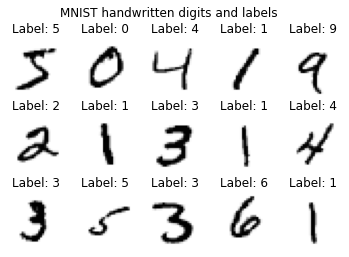

In [3]:
import matplotlib.pyplot as plt                         #Will be used to display images
plt.suptitle('MNIST handwritten digits and labels')
for i in range(0,15):
    plt.subplot(3,5,i+1)
    plt.axis('off')
    plt.title(f'Label: {labels[i]}')
    plt.imshow(images[i].reshape(28,28),cmap="Greys")   #Images are 28x28 pixels in size

## Applying The k-NN Classifier

With the MNIST data properly stored,the k-NN classifier can now be applied. Writing a function that produces a display of the output will be beneficial. In doing so, including an argument for k will allow for analysis of the algorithm's performance for a wide variety of k values

In [4]:
import math
def display_knn_application(img,kval):
    """
    Displays the predicted value of the input image, along with a subplot of its k-nearest neighbors.

    img:
        Numpy array representative of an MNIST image.
    kval:
        Number of nearest neighbors.
    """
    predicted,neighbors=knn_classifier(images,labels,img,kval) #Apply knn classifier
    plt.title(f'Predicted label: {predicted}')
    plt.axis('off')
    plt.imshow(img.reshape(28,28),cmap="Greys")                #MNIST images are 28x28 pixels
    plt.show()
    plt.suptitle(f"{kval} Nearest Neighbors")
    plt.subplots_adjust(hspace=1.05)
    for i in range(0,kval):                                    #Generate subplots of k-nearest neighbors
        plt.subplot(int(math.ceil(kval/5)),5,i+1)
        plt.title(f'#{i+1}')
        plt.axis('off')
        plt.imshow(neighbors[i].reshape(28,28),cmap="Greys")   #MNIST images are 28x28 pixels
    return

The classifier's output will now be displayed for the first image of the MNIST dataset, with a k value of 20.

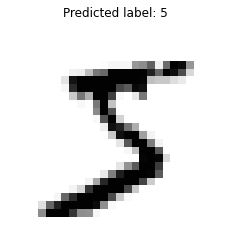

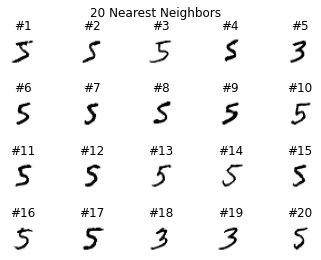

In [5]:
display_knn_application(images[0],20)

Observably, the image was accurately classified as the digit 5, and 17 out of the 20 nearest neighbors were also the digit 5. This indicates that the method of using Euclidean distance to compare the images is rather successful. 

However, the 5th, 18th and 19th neighbors are the digit 3, which is an interesting result. Potential reasoning for this is that the digits 3 and 5 have a similar shape and the algorithm occasionally misclassifies them. This hypothesis will be explored.

## Confusion Between Similar Digits ##
To test the algorithm more and explore inaccuracy involving confusion between similar shaped digits, we will examine more displayed outputs.

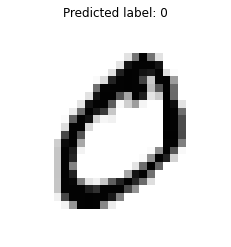

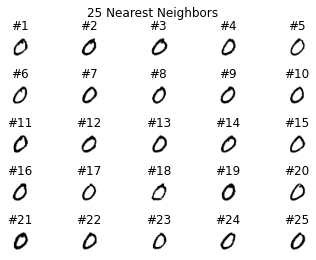

In [6]:
display_knn_application(images[1],25)

This output consisted of no mis-classified nearest neighbors! Perhaps 0 is very distinguishable from other numbers, or the digit 5 is more complex to recognize.

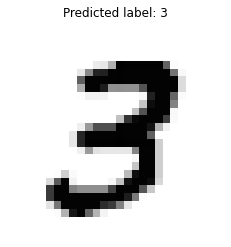

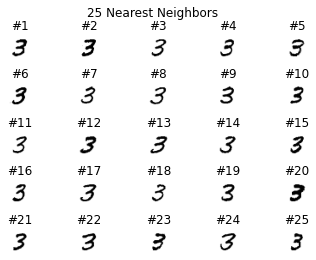

In [7]:
display_knn_application(images[7],25)

Interestingly, the algorithm seems to correctly classify nearest neighbors when a data point of the digit 3 is input. However, our previous input of 5 consisted of mis-classified nearest neighbors of the digit 3. We will now display another classification of an input of 5 to further analyze the dilemma.

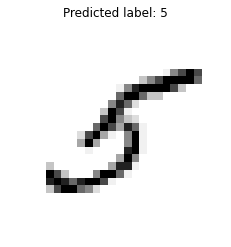

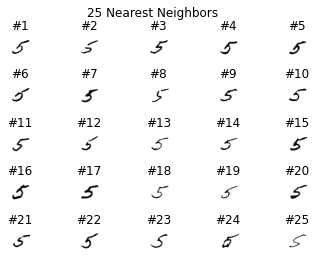

In [8]:
display_knn_application(images[35],25)

Surprisingly, the algorithm's output did not include any mis-classified neighbors as previously observed. Perhaps the mis-classification of a digit 5's nearest neighbors was simply due to the way the digit was sloppily written.

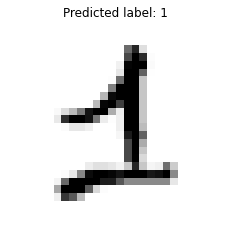

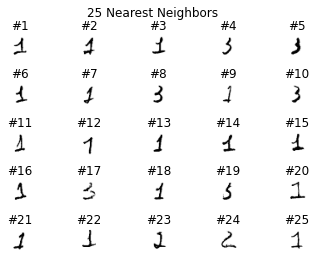

In [9]:
display_knn_application(images[24],25)

Another case which has multiple digits as nearest neighbors! The inputted digit 1 seems to have been written rather uniquely in this case, which further supports the idea that mis-classified neighbors are mainly due to the manner in which the digit was drawn. The predicted value remains correct, however this could seemingly introduce problems for the algorithm with a small value of k. However, since the #1 nearest neighbor is actually the inputted data point itself, it is likely that the issue of the digit being mis-classified will be a rare occurence of extremely sloppy handwriting.

## Accuracy Dependence on k ##

The accuracy of the k-Nearest Neighbor classifier may be directly impacted by parameterization. The value of k is one specification that should have an effect on performance. A method of analyzing the performance of different values of k would is to compute the percentage of accurate predictions. A function which can be used to test the accuracy at varying values of k will be constructed. This function will consider 20% of the training data in testing to cut down runtime.

In [10]:
def test_accuracy(k,a):
    """
    Tests the accuracy of k-NN predictions.
    Note that computation may take long periods of time for large values of a.
    
    k:
        Number of nearest neighbors.
    a:
        Number of predictions to sample
    """
    correct=0                                                                      #Track how many predictions were correct
    count=0
    for i in range(0,a):
        predicted,neighbors=knn_classifier(images[:int(len(images)/5)],labels,images[i],k)#20% of images for testing data
        if predicted==labels[i]:
            correct+=1
        count+=1
    return float(correct)/float(count)                                             #Return the percentage of correct predictions

Now, the function will be applied to a wide variety of k values to analyze potential trends as k values increase. Note that that the predictions will be sampled 50 times per k-value to prevent excessive runtime. This means that the accuracy will be a multiple of 0.02.

In [11]:
print(f"Testing with {int(60000/5)} training data points")
for i in range(2,230,35):
    print("Computing...")
    print(f'k-value: {i}; Accuracy: {test_accuracy(i,50)}')

Testing with 12000 training data points
Computing...
k-value: 2; Accuracy: 1.0
Computing...
k-value: 37; Accuracy: 0.96
Computing...
k-value: 72; Accuracy: 0.92
Computing...
k-value: 107; Accuracy: 0.9
Computing...
k-value: 142; Accuracy: 0.88
Computing...
k-value: 177; Accuracy: 0.86
Computing...
k-value: 212; Accuracy: 0.86


As expected, the prediction accuracy decreases as the value of k increases. An idea to find the optimal tuning for k is to compute the ratio of k to the amount of training data, as the accuracy drops from a preferred accuracy. For example, the tests provide a rough estimate for the value of k prior to dropping below 0.90 accuracy: approximately `0.009%` of the amount of data points in the fitted training data. This is found by dividing the k-value at 0.90 accuracy by the amount of data points, which is 12,000 in this case.

## Conclusion ##

The k-Nearest Neighbors algorithm proved to be a useful tool for classifying handwritten digits in the MNIST dataset. The high accuracy achieved indicates that the k-NN algorithm could potentially be used reliably for more complex image recognition tasks. The k-NN algorithm shows to provide data scientists an extremely powerful tool for classification with countless applications of significance.

## References ##

- LeCun, Y., Cortes, C., & Burges, C. (1998). The MNIST database of handwritten digits. http://yann.lecun.com/exdb/mnist/